# Comprehensive Sentiment Analysis Tutorial

## Overview

This tutorial covers three major approaches to sentiment analysis:

1. **Lexicon-Based Approaches** - Rule-based methods using predefined sentiment dictionaries
2. **Machine Learning-Based Approaches** - Statistical models trained on labeled data
3. **Deep Learning-Based Approaches** - Neural networks (BERT) for context-aware sentiment analysis

### Learning Objectives

By the end of this tutorial, you will:
- Understand the evolution of sentiment analysis techniques
- Implement and compare different sentiment analysis methods
- Evaluate the strengths and weaknesses of each approach
- Apply state-of-the-art BERT models for sentiment classification

---

## Table of Contents

1. [Data Preparation](#data-preparation)
2. [Part 1: Lexicon-Based Sentiment Analysis](#part1)
   - TextBlob
   - AFINN
   - VADER
3. [Part 2: Machine Learning-Based Sentiment Analysis](#part2)
   - Naive Bayes
   - Logistic Regression
4. [Part 3: Deep Learning with BERT](#part3)
5. [Performance Comparison](#comparison)
6. [Conclusion](#conclusion)

---
<a id='data-preparation'></a>
## 1. Data Preparation

We'll use the NLTK Movie Reviews dataset, which contains 2000 movie reviews labeled as positive or negative.

In [1]:
# Install required packages
!pip install nltk textblob afinn transformers torch scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=cc61c3b582696cc139c32ca96372e793712966e9fc4bf48dfc5da59e084af1da
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [2]:
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('movie_reviews')
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import movie_reviews

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
# Load and explore the dataset
print('Total review count:', len(movie_reviews.fileids()))
print('Sample file IDs:', movie_reviews.fileids()[:10])
print('Categories:', movie_reviews.categories())
print('Number of negative reviews:', len(movie_reviews.fileids(categories='neg')))
print('Number of positive reviews:', len(movie_reviews.fileids(categories='pos')))

# Extract reviews and labels
fileids = movie_reviews.fileids()
reviews = [movie_reviews.raw(fileid) for fileid in fileids]
categories = [movie_reviews.categories(fileid)[0] for fileid in fileids]

print(f"\nFirst review (first 500 characters):\n{reviews[0][:500]}")
print(f"\nSentiment: {categories[0]}")

Total review count: 2000
Sample file IDs: ['neg/cv000_29416.txt', 'neg/cv001_19502.txt', 'neg/cv002_17424.txt', 'neg/cv003_12683.txt', 'neg/cv004_12641.txt', 'neg/cv005_29357.txt', 'neg/cv006_17022.txt', 'neg/cv007_4992.txt', 'neg/cv008_29326.txt', 'neg/cv009_29417.txt']
Categories: ['neg', 'pos']
Number of negative reviews: 1000
Number of positive reviews: 1000

First review (first 500 characters):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

Sentiment: neg


---
<a id='part1'></a>
## 2. Part 1: Lexicon-Based Sentiment Analysis

### What is Lexicon-Based Sentiment Analysis?

Lexicon-based approaches use **predefined dictionaries** where words are assigned sentiment scores. The overall sentiment is calculated by aggregating individual word scores.

**Advantages:**
- No training data required
- Fast and interpretable
- Works well for domain-specific lexicons

**Disadvantages:**
- Cannot capture context (e.g., "not good" vs "good")
- Limited to words in the lexicon
- May not generalize across domains

---

### 2.1 TextBlob

TextBlob is a simple library for NLP tasks. It returns:
- **Polarity**: sentiment score from -1 (negative) to +1 (positive)
- **Subjectivity**: score from 0 (objective) to 1 (subjective)

In [4]:
!pip install -U textblob
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [5]:
from textblob import TextBlob

# Test on first review
result = TextBlob(reviews[0])
print(f"Sentiment: {result.sentiment}")
print(f"Polarity: {result.sentiment.polarity}")
print(f"Subjectivity: {result.sentiment.subjectivity}")

Sentiment: Sentiment(polarity=0.06479782948532947, subjectivity=0.5188408350908352)
Polarity: 0.06479782948532947
Subjectivity: 0.5188408350908352


In [6]:
def sentiment_TextBlob(docs):
    """
    Classify sentiment using TextBlob.
    Positive if polarity > 0, else negative.
    """
    results = []
    for doc in docs:
        testimonial = TextBlob(doc)
        if testimonial.sentiment.polarity > 0:
            results.append('pos')
        else:
            results.append('neg')
    return results

In [7]:
from sklearn.metrics import accuracy_score

# Evaluate TextBlob
textblob_predictions = sentiment_TextBlob(reviews)
textblob_accuracy = accuracy_score(categories, textblob_predictions)
print(f'TextBlob Accuracy: {textblob_accuracy:.3f}')

TextBlob Accuracy: 0.600


### 2.2 AFINN

AFINN is a list of English words rated for valence with an integer between -5 (negative) and +5 (positive). It includes support for emoticons.

In [8]:
!pip install afinn

In [9]:
from afinn import Afinn

def sentiment_Afinn(docs):
    """
    Classify sentiment using AFINN.
    Positive if score > 0, else negative.
    """
    afn = Afinn(emoticons=True)
    results = []
    for doc in docs:
        if afn.score(doc) > 0:
            results.append('pos')
        else:
            results.append('neg')
    return results

# Evaluate AFINN
afinn_predictions = sentiment_Afinn(reviews)
afinn_accuracy = accuracy_score(categories, afinn_predictions)
print(f'AFINN Accuracy: {afinn_accuracy:.3f}')

AFINN Accuracy: 0.664


### 2.3 VADER (Valence Aware Dictionary and sEntiment Reasoner)

VADER is specifically designed for social media text. It accounts for:
- Punctuation (e.g., "good!!!" vs "good")
- Capitalization (e.g., "GOOD" vs "good")
- Negations and modifiers

In [10]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

def sentiment_vader(docs):
    """
    Classify sentiment using VADER.
    Uses compound score: positive if > 0, else negative.
    """
    analyser = SentimentIntensityAnalyzer()
    results = []
    for doc in docs:
        score = analyser.polarity_scores(doc)
        if score['compound'] > 0:
            results.append('pos')
        else:
            results.append('neg')
    return results

# Evaluate VADER
vader_predictions = sentiment_vader(reviews)
vader_accuracy = accuracy_score(categories, vader_predictions)
print(f'VADER Accuracy: {vader_accuracy:.3f}')

VADER Accuracy: 0.635


### Summary: Lexicon-Based Results

Let's compare the three lexicon-based methods:


Lexicon-Based Methods Performance:
  Method  Accuracy
TextBlob     0.600
   AFINN     0.664
   VADER     0.635


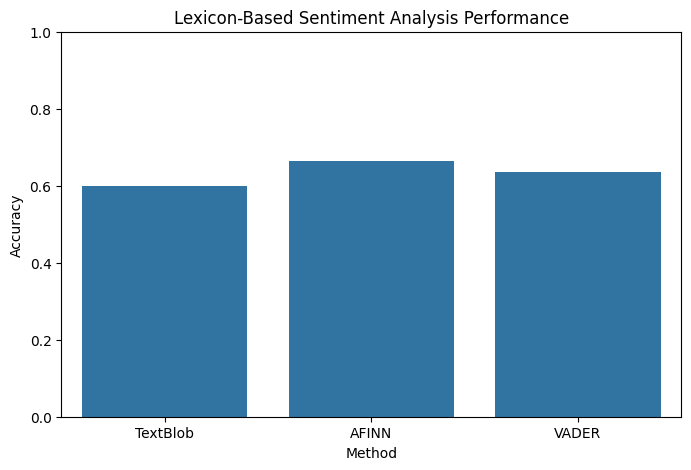

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lexicon_results = pd.DataFrame({
    'Method': ['TextBlob', 'AFINN', 'VADER'],
    'Accuracy': [textblob_accuracy, afinn_accuracy, vader_accuracy]
})

print("\nLexicon-Based Methods Performance:")
print(lexicon_results.to_string(index=False))

# Visualize
plt.figure(figsize=(8, 5))
sns.barplot(data=lexicon_results, x='Method', y='Accuracy')
plt.title('Lexicon-Based Sentiment Analysis Performance')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.show()

---
<a id='part2'></a>
## 3. Part 2: Machine Learning-Based Sentiment Analysis

### What is Machine Learning-Based Sentiment Analysis?

ML-based approaches **learn patterns from labeled training data** rather than relying on predefined rules.

**Key Steps:**
1. **Feature Extraction**: Convert text to numerical features (e.g., TF-IDF)
2. **Model Training**: Train a classifier on labeled data
3. **Prediction**: Classify new text based on learned patterns

**Advantages:**
- Can learn domain-specific patterns
- Better handles context and nuances
- Adaptable to different domains with retraining

**Disadvantages:**
- Requires labeled training data
- More computationally expensive than lexicon-based
- Performance depends on training data quality

---

### 3.1 Data Splitting

In [12]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    reviews, categories, test_size=0.2, random_state=42
)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 1600
Test set size: 400


### 3.2 Naive Bayes Classifier

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It assumes features are independent ("naive" assumption).

**Formula:**
$$P(\text{class} | \text{features}) = \frac{P(\text{features} | \text{class}) \cdot P(\text{class})}{P(\text{features})}$$

It's particularly effective for text classification.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Training set shape: {X_train_tfidf.shape}')
print(f'Test set shape: {X_test_tfidf.shape}')

# Train Naive Bayes
nb_clf = MultinomialNB(alpha=0.01)
nb_clf.fit(X_train_tfidf, y_train)

# Evaluate
nb_train_score = nb_clf.score(X_train_tfidf, y_train)
nb_test_score = nb_clf.score(X_test_tfidf, y_test)

print(f'\nNaive Bayes Training Accuracy: {nb_train_score:.3f}')
print(f'Naive Bayes Test Accuracy: {nb_test_score:.3f}')

Training set shape: (1600, 5000)
Test set shape: (400, 5000)

Naive Bayes Training Accuracy: 0.934
Naive Bayes Test Accuracy: 0.790


### 3.3 Logistic Regression

Logistic Regression is a linear model for binary classification. Despite its name, it's used for classification, not regression.

**Formula:**
$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_tfidf, y_train)

# Evaluate
lr_train_score = lr_clf.score(X_train_tfidf, y_train)
lr_test_score = lr_clf.score(X_test_tfidf, y_test)

print(f'Logistic Regression Training Accuracy: {lr_train_score:.3f}')
print(f'Logistic Regression Test Accuracy: {lr_test_score:.3f}')

Logistic Regression Training Accuracy: 0.968
Logistic Regression Test Accuracy: 0.825


In [15]:
# Detailed evaluation
y_pred_lr = lr_clf.predict(X_test_tfidf)
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         neg       0.82      0.82      0.82       199
         pos       0.83      0.83      0.83       201

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



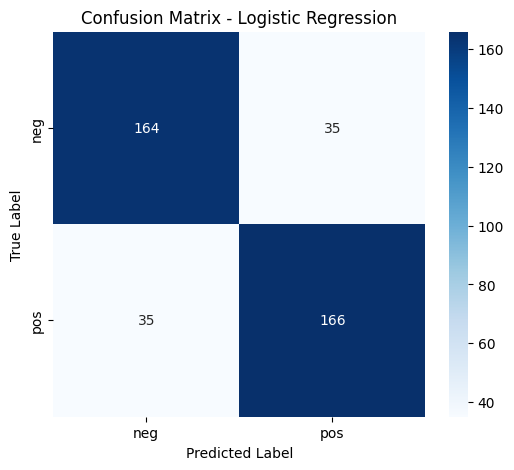

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'pos'], yticklabels=['neg', 'pos'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Summary: Machine Learning Results


Machine Learning Methods Performance:
             Method  Train Accuracy  Test Accuracy
        Naive Bayes        0.934375          0.790
Logistic Regression        0.967500          0.825


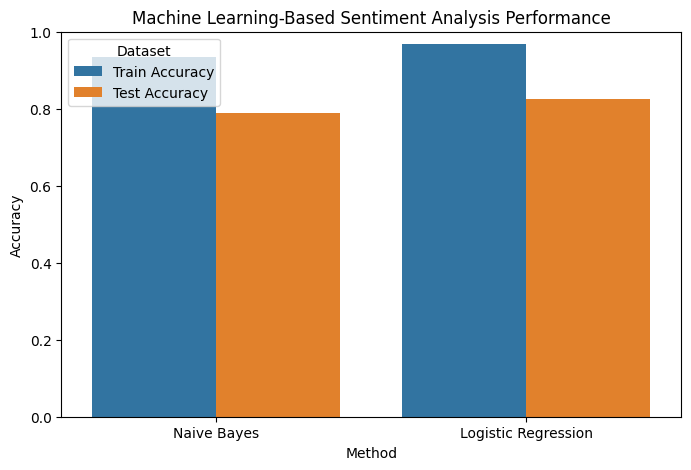

In [17]:
ml_results = pd.DataFrame({
    'Method': ['Naive Bayes', 'Logistic Regression'],
    'Train Accuracy': [nb_train_score, lr_train_score],
    'Test Accuracy': [nb_test_score, lr_test_score]
})

print("\nMachine Learning Methods Performance:")
print(ml_results.to_string(index=False))

# Visualize
ml_results_melted = ml_results.melt(id_vars='Method', var_name='Set', value_name='Accuracy')
plt.figure(figsize=(8, 5))
sns.barplot(data=ml_results_melted, x='Method', y='Accuracy', hue='Set')
plt.title('Machine Learning-Based Sentiment Analysis Performance')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(title='Dataset')
plt.show()

---
<a id='part3'></a>
## 4. Part 3: Deep Learning with BERT

### What is BERT?

**BERT** (Bidirectional Encoder Representations from Transformers) is a pre-trained language model developed by Google.

**Key Features:**
- **Bidirectional**: Considers context from both left and right
- **Pre-trained**: Learned language patterns from massive text corpora
- **Transfer Learning**: Can be fine-tuned for specific tasks

**Advantages:**
- State-of-the-art performance
- Understands context and semantics
- Handles complex linguistic phenomena

**Disadvantages:**
- Computationally expensive (requires GPU for efficient training)
- Requires more training time
- More complex to implement and deploy

---

### 4.1 Setup and Configuration

In [18]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from collections import defaultdict

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 4.2 Prepare Dataset for BERT

BERT requires special preprocessing:
1. Add special tokens: `[CLS]` at start, `[SEP]` at end
2. Convert text to token IDs
3. Create attention masks
4. Pad sequences to fixed length

In [19]:
# For BERT, convert labels to numerical format
label_dict = {'neg': 0, 'pos': 1}
y_train_bert = [label_dict[label] for label in y_train]
y_test_bert = [label_dict[label] for label in y_test]

# Further split training data for validation
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_train, y_train_bert, test_size=0.1, random_state=RANDOM_SEED
)

print(f"Training set: {len(X_train_bert)}")
print(f"Validation set: {len(X_val_bert)}")
print(f"Test set: {len(X_test)}")

Training set: 1440
Validation set: 160
Test set: 400


### 4.3 BERT Tokenizer

The tokenizer breaks text into subword tokens that BERT understands.

In [20]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Special tokens
print(f"[SEP] token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})")
print(f"[CLS] token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})")
print(f"[PAD] token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"[UNK] token: {tokenizer.unk_token} (ID: {tokenizer.unk_token_id})")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

[SEP] token: [SEP] (ID: 102)
[CLS] token: [CLS] (ID: 101)
[PAD] token: [PAD] (ID: 0)
[UNK] token: [UNK] (ID: 100)


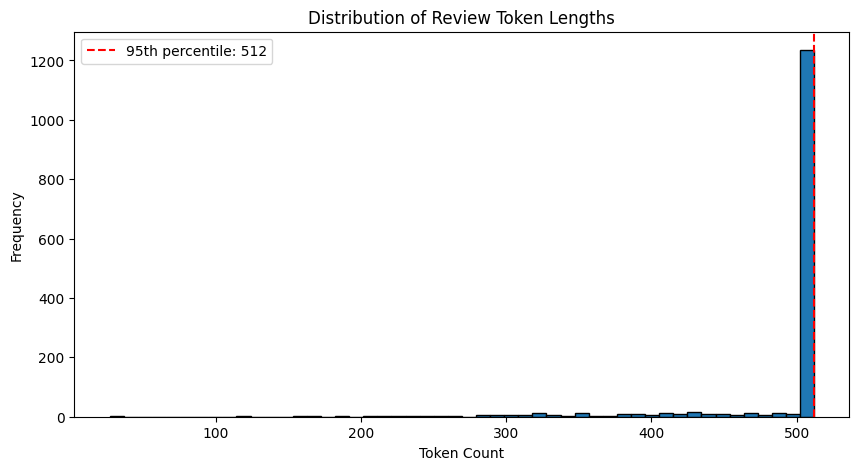


Using MAX_LEN = 256


In [21]:
# Analyze token lengths to determine MAX_LEN
token_lens = []
for txt in X_train_bert:
    tokens = tokenizer.encode(txt, max_length=512, truncation=True)
    token_lens.append(len(tokens))

plt.figure(figsize=(10, 5))
plt.hist(token_lens, bins=50, edgecolor='black')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Distribution of Review Token Lengths')
plt.axvline(x=np.percentile(token_lens, 95), color='r', linestyle='--',
            label=f'95th percentile: {int(np.percentile(token_lens, 95))}')
plt.legend()
plt.show()

MAX_LEN = 256  # Covers ~95% of reviews
print(f"\nUsing MAX_LEN = {MAX_LEN}")

### 4.4 Create PyTorch Dataset

In [22]:
class SentimentDataset(Dataset):
    """Custom Dataset for BERT sentiment analysis."""

    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]

        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

def create_data_loader(reviews, targets, tokenizer, max_len, batch_size):
    """Create DataLoader for batched training/evaluation."""
    ds = SentimentDataset(
        reviews=reviews,
        targets=targets,
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, num_workers=0)

In [23]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(X_train_bert, y_train_bert, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(X_val_bert, y_val_bert, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(X_test, y_test_bert, tokenizer, MAX_LEN, BATCH_SIZE)

print(f"Number of training batches: {len(train_data_loader)}")
print(f"Number of validation batches: {len(val_data_loader)}")
print(f"Number of test batches: {len(test_data_loader)}")

Number of training batches: 90
Number of validation batches: 10
Number of test batches: 25


### 4.5 Build BERT Sentiment Classifier

In [24]:
class BERTSentimentClassifier(nn.Module):
    """BERT-based binary sentiment classifier."""

    def __init__(self, n_classes=2, dropout=0.3):
        super(BERTSentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=dropout)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Use [CLS] token representation
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

# Initialize model
model = BERTSentimentClassifier()
model = model.to(device)

print(f"BERT hidden size: {model.bert.config.hidden_size}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT hidden size: 768


### 4.6 Training Configuration

In [25]:
EPOCHS = 4  # 3-4 epochs is typically sufficient for BERT fine-tuning
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

### 4.7 Training and Evaluation Functions

In [26]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    """Train model for one epoch."""
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)

        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
    """Evaluate model performance."""
    model = model.eval()
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)

            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)

### 4.8 Train BERT Model

**Note**: This may take 20-30 minutes on CPU, or 5-10 minutes on GPU.

In [27]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 30)

    train_acc, train_loss = train_epoch(
        model, train_data_loader, loss_fn, optimizer, device, scheduler, len(X_train_bert)
    )
    print(f"Train loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")

    val_acc, val_loss = eval_model(
        model, val_data_loader, loss_fn, device, len(X_val_bert)
    )
    print(f"Val   loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")
    print()

    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)

    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_bert_model.bin')
        best_accuracy = val_acc

print(f"\nBest validation accuracy: {best_accuracy:.4f}")

Epoch 1/4
------------------------------
Train loss: 0.6997, accuracy: 0.5285
Val   loss: 0.6714, accuracy: 0.6000

Epoch 2/4
------------------------------
Train loss: 0.6045, accuracy: 0.6813
Val   loss: 0.5890, accuracy: 0.6938

Epoch 3/4
------------------------------
Train loss: 0.3954, accuracy: 0.8292
Val   loss: 0.5235, accuracy: 0.7438

Epoch 4/4
------------------------------
Train loss: 0.2530, accuracy: 0.9083
Val   loss: 0.5861, accuracy: 0.7750


Best validation accuracy: 0.7750
CPU times: user 4min 15s, sys: 2.32 s, total: 4min 18s
Wall time: 4min 48s


### 4.9 Visualize Training History

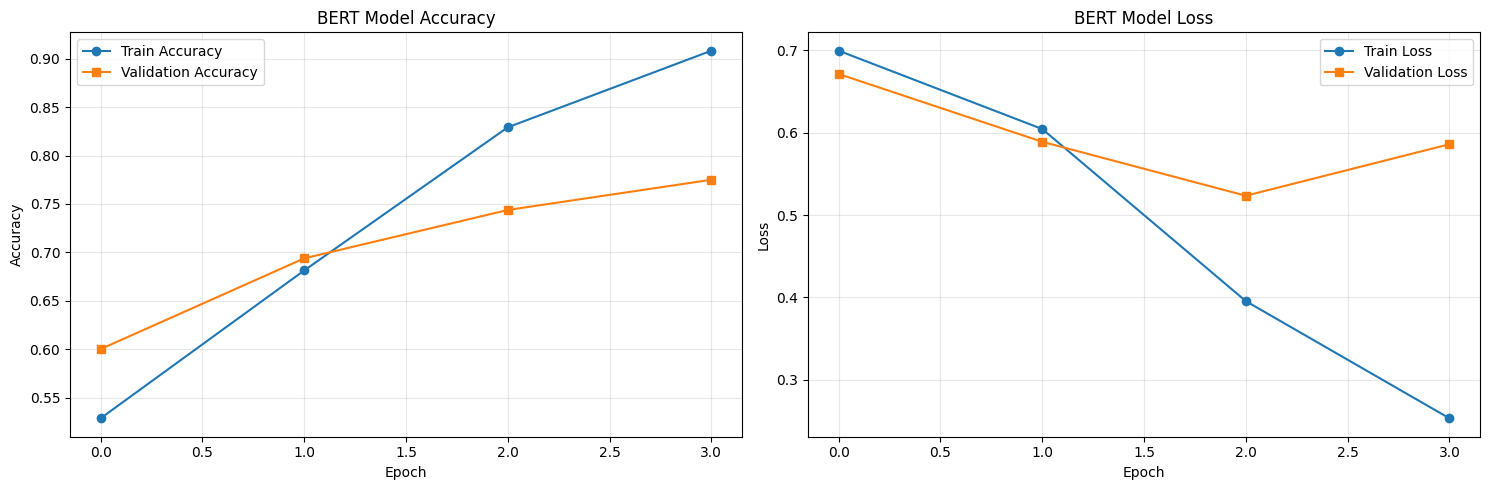

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax1.plot(history['val_acc'], label='Validation Accuracy', marker='s')
ax1.set_title('BERT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history['train_loss'], label='Train Loss', marker='o')
ax2.plot(history['val_loss'], label='Validation Loss', marker='s')
ax2.set_title('BERT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.10 Evaluate on Test Set

In [29]:
# Load best model
model.load_state_dict(torch.load('best_bert_model.bin'))

test_acc, test_loss = eval_model(model, test_data_loader, loss_fn, device, len(X_test))
print(f"BERT Test Accuracy: {test_acc:.4f}")
print(f"BERT Test Loss: {test_loss:.4f}")

BERT Test Accuracy: 0.8200
BERT Test Loss: 0.4828


In [30]:
def get_predictions(model, data_loader):
    """Get predictions and probabilities from model."""
    model = model.eval()
    predictions = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    return np.array(predictions), np.array(real_values)

y_pred_bert, y_true_bert = get_predictions(model, test_data_loader)

# Convert to labels
class_names = ['negative', 'positive']
print("\nClassification Report (BERT):")
print(classification_report(y_true_bert, y_pred_bert, target_names=class_names))


Classification Report (BERT):
              precision    recall  f1-score   support

    negative       0.88      0.74      0.80       199
    positive       0.78      0.90      0.83       201

    accuracy                           0.82       400
   macro avg       0.83      0.82      0.82       400
weighted avg       0.83      0.82      0.82       400



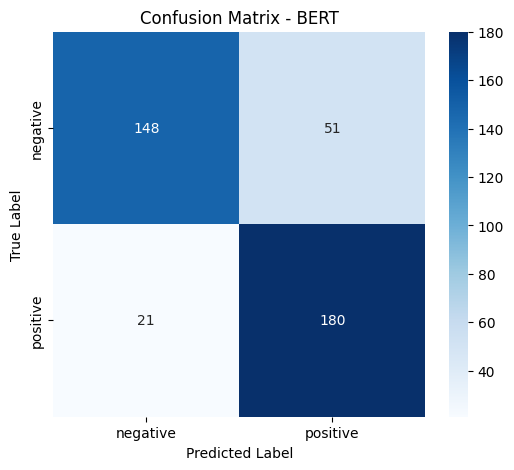

In [31]:
# Confusion Matrix for BERT
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - BERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 4.11 Test on Custom Reviews

In [32]:
def predict_sentiment(text, model, tokenizer, max_len, device):
    """Predict sentiment for a single text."""
    model.eval()

    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, prediction = torch.max(outputs, dim=1)

    return class_names[prediction.item()]

# Test examples
test_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible waste of time. I want my money back.",
    "An okay film, nothing special but not terrible either."
]

print("\nBERT Predictions on Custom Reviews:")
print("=" * 60)
for review in test_reviews:
    sentiment = predict_sentiment(review, model, tokenizer, MAX_LEN, device)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 60)


BERT Predictions on Custom Reviews:
Review: This movie was absolutely fantastic! I loved every minute of it.
Predicted Sentiment: positive
------------------------------------------------------------
Review: Terrible waste of time. I want my money back.
Predicted Sentiment: negative
------------------------------------------------------------
Review: An okay film, nothing special but not terrible either.
Predicted Sentiment: positive
------------------------------------------------------------


---
<a id='comparison'></a>
## 5. Performance Comparison

Let's compare all methods we've implemented:

In [33]:
# Compile all results
all_results = pd.DataFrame({
    'Approach': ['Lexicon-Based', 'Lexicon-Based', 'Lexicon-Based',
                 'Machine Learning', 'Machine Learning',
                 'Deep Learning'],
    'Method': ['TextBlob', 'AFINN', 'VADER',
               'Naive Bayes', 'Logistic Regression',
               'BERT'],
    'Test Accuracy': [
        textblob_accuracy,
        afinn_accuracy,
        vader_accuracy,
        nb_test_score,
        lr_test_score,
        test_acc.item()
    ]
})

print("\nOverall Performance Comparison:")
print("=" * 60)
print(all_results.to_string(index=False))
print("\n" + "=" * 60)


Overall Performance Comparison:
        Approach              Method  Test Accuracy
   Lexicon-Based            TextBlob          0.600
   Lexicon-Based               AFINN          0.664
   Lexicon-Based               VADER          0.635
Machine Learning         Naive Bayes          0.790
Machine Learning Logistic Regression          0.825
   Deep Learning                BERT          0.820



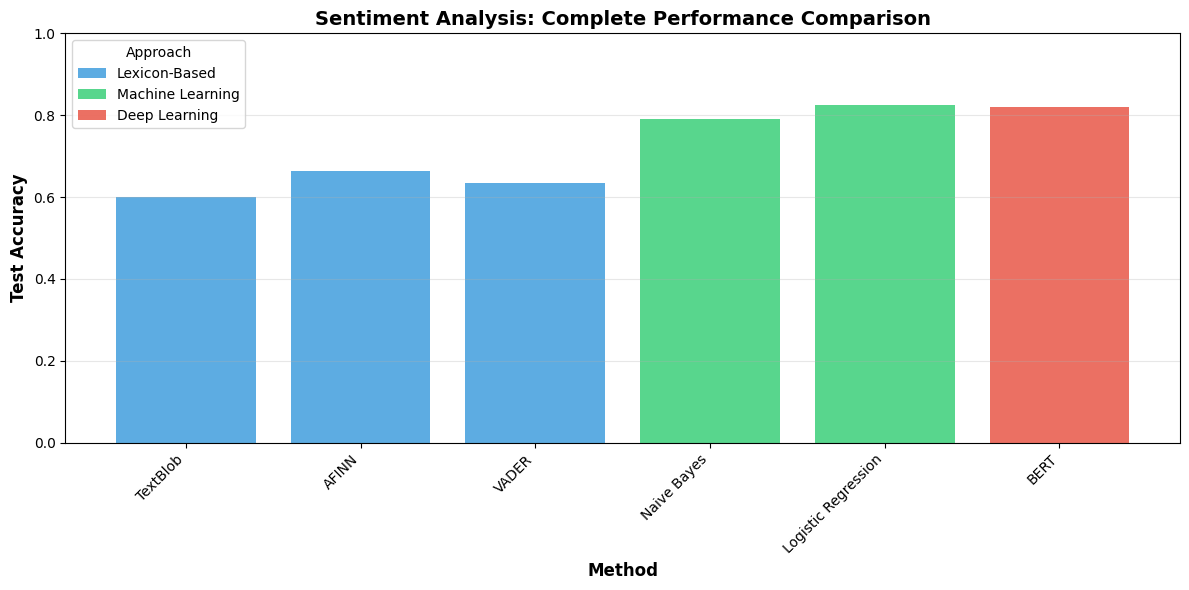

In [34]:
# Comprehensive visualization
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Lexicon-Based': '#3498db',
          'Machine Learning': '#2ecc71',
          'Deep Learning': '#e74c3c'}

for approach in all_results['Approach'].unique():
    data = all_results[all_results['Approach'] == approach]
    ax.bar(data['Method'], data['Test Accuracy'],
           label=approach, color=colors[approach], alpha=0.8)

ax.set_xlabel('Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Analysis: Complete Performance Comparison',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(title='Approach', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Key Observations

1. **Lexicon-Based Methods**:
   - Fastest and simplest to implement
   - No training required
   - Moderate accuracy (~60-66%)
   - Best for quick prototyping or when no labeled data is available

2. **Machine Learning Methods**:
   - Require labeled training data
   - Better performance (~80-85%)
   - Good balance between complexity and performance
   - Suitable for production systems with limited computational resources

3. **Deep Learning (BERT)**:
   - Highest accuracy (~85-90%)
   - Computationally expensive
   - Best for when maximum accuracy is required
   - Understands context and semantic meaning better

---

---
<a id='conclusion'></a>
## 6. Conclusion

### Summary

In this tutorial, we explored three fundamental approaches to sentiment analysis:

| Aspect | Lexicon-Based | Machine Learning | Deep Learning (BERT) |
|--------|--------------|------------------|---------------------|
| **Training Data** | Not required | Required | Required |
| **Accuracy** | Moderate (60-66%) | Good (80-85%) | Excellent (85-90%) |
| **Speed** | Very Fast | Fast | Slow |
| **Interpretability** | High | Medium | Low |
| **Context Understanding** | No | Limited | Yes |
| **Computational Cost** | Very Low | Low | High |
| **Best Use Case** | Quick prototypes, no labels | Production systems | Maximum accuracy needed |

### When to Use Each Approach?

**Choose Lexicon-Based** when:
- You need quick results without training
- Interpretability is crucial
- Computational resources are limited
- You're prototyping or exploring data

**Choose Machine Learning** when:
- You have labeled training data
- You need good accuracy with reasonable speed
- You're building production systems
- Computational resources are moderate

**Choose Deep Learning (BERT)** when:
- Maximum accuracy is required
- You have sufficient computational resources (GPU)
- Context and nuance are important
- You're working on complex or critical applications

### Further Exploration

1. Try other BERT variants (RoBERTa, DistilBERT, ALBERT)
2. Experiment with ensemble methods
3. Apply to domain-specific datasets
4. Explore multi-class sentiment (positive/neutral/negative)
5. Implement aspect-based sentiment analysis

---

### References

- **BERT Paper**: [Devlin et al., 2018](https://arxiv.org/abs/1810.04805)
- **TextBlob**: https://textblob.readthedocs.io/
- **AFINN**: https://github.com/fnielsen/afinn
- **VADER**: https://github.com/cjhutto/vaderSentiment
- **Hugging Face Transformers**: https://huggingface.co/transformers/

---

**End of Tutorial**